In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


/var/folders/j5/4qjg89qx7t91f5g_m9523jd00000gn/T/ipykernel_81219/61244965.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  x2_left = patches.Circle((-0.2, 0), radius=0.2, color=color_X2, edgecolor='white', lw=0.5, zorder=5)
/var/folders/j5/4qjg89qx7t91f5g_m9523jd00000gn/T/ipykernel_81219/61244965.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  x2_right = patches.Circle((0.2, 0), radius=0.2, color=color_X2, edgecolor='white', lw=0.5, zorder=5)


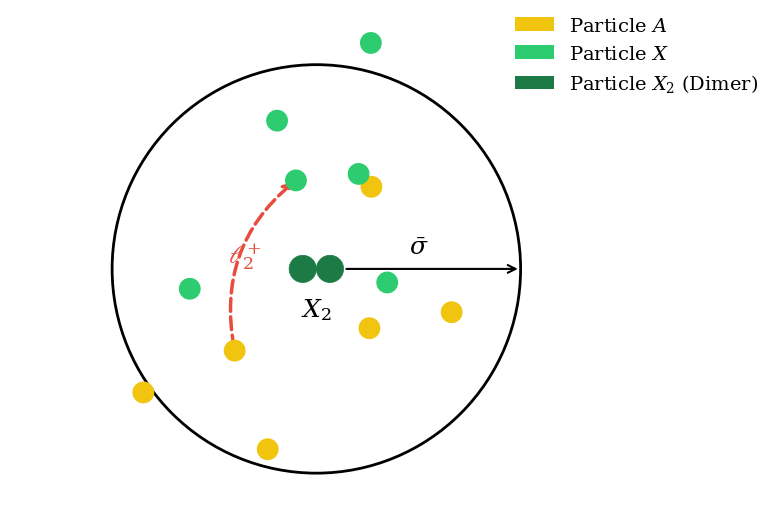

In [13]:

# 1. Use a serif font so it looks like it belongs in a LaTeX document!
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 14
})

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal') # Forces the circle to be perfectly round, not an oval
ax.axis('off')         # Hide the axes lines and numbers

# 2. Crisp, flat academic colors
color_A = '#F1C40F'    # Solid Yellow for A
color_X = '#2ECC71'    # Solid Green for X
color_X2 = "#1C7B44"   # Slightly darker green for the X2 dimer

sigma = 3.0

# 3. Draw the reactive region boundary
boundary = patches.Circle((0, 0), radius=sigma, fill=False, edgecolor='black', linewidth=2, zorder=1)
ax.add_patch(boundary)

# 4. Draw X_2 at the center (A proper dimer of two touching green circles!)
x2_left = patches.Circle((-0.2, 0), radius=0.2, color=color_X2, edgecolor='white', lw=0.5, zorder=5)
x2_right = patches.Circle((0.2, 0), radius=0.2, color=color_X2, edgecolor='white', lw=0.5, zorder=5)
ax.add_patch(x2_left)
ax.add_patch(x2_right)
ax.text(0, -0.4, r'$X_2$', ha='center', va='top', fontsize=18)

# 5. Draw the radius arrow for \bar{\sigma}
ax.annotate(
    '', xy=(sigma, 0), xytext=(0.4, 0),
    arrowprops=dict(arrowstyle='->', lw=1.5, color='black')
)
ax.text(sigma/2, 0.15, r'$\bar{\sigma}$', ha='center', va='bottom', fontsize=18)

# 6. Add the specific conversion reaction: A -> X
pos_A = np.array([-1.2, -1.2])
pos_X_new = np.array([-0.3, 1.3])

particle_A_react = patches.Circle(pos_A, radius=0.15, color=color_A, zorder=4)
particle_X_new = patches.Circle(pos_X_new, radius=0.15, color=color_X, zorder=4)
ax.add_patch(particle_A_react)
ax.add_patch(particle_X_new)

# Draw the curved dashed red arrow showing the conversion
ax.annotate(
    '', xy=pos_X_new, xytext=pos_A,
    arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=2.5, ls='--', connectionstyle="arc3,rad=-0.3")
)
# Label the reaction rate next to the arrow!
ax.text(-1.3, 0.1, r'$\ell_2^+$', color='#E74C3C', fontsize=18, fontweight='bold')

# 7. Scatter some random background A and X particles
np.random.seed(42) # Keeps the random positions the same every time you run it
for _ in range(5):
    r = np.random.uniform(1.0, sigma * 1.3)
    theta = np.random.uniform(0, 2*np.pi)
    ax.add_patch(patches.Circle((r*np.cos(theta), r*np.sin(theta)), radius=0.15, color=color_A, zorder=3))

for _ in range(5):
    r = np.random.uniform(1.0, sigma * 1.3)
    theta = np.random.uniform(0, 2*np.pi)
    ax.add_patch(patches.Circle((r*np.cos(theta), r*np.sin(theta)), radius=0.15, color=color_X, zorder=3))

# 8. Add a custom Legend
legend_elements = [
    patches.Patch(facecolor=color_A, edgecolor='none', label='Particle $A$'),
    patches.Patch(facecolor=color_X, edgecolor='none', label='Particle $X$'),
    patches.Patch(facecolor=color_X2, edgecolor='none', label='Particle $X_2$ (Dimer)')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.25, 1.05), frameon=False, fontsize=14)

# 9. Set limits and Save
ax.set_xlim(-sigma*1.5, sigma*1.5)
ax.set_ylim(-sigma*1.2, sigma*1.2)

plt.tight_layout()
# Saving as a PDF ensures it will be a perfectly sharp vector graphic in your LaTeX thesis!
# plt.savefig("reaction_schematic.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import matplotlib.cm as cm
cmap = cm.get_cmap('Set2')

/var/folders/j5/4qjg89qx7t91f5g_m9523jd00000gn/T/ipykernel_81219/2074396472.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set2')


ratio of the second channel: 5.9005
ratio of the second channel: 5.9529
ratio of the second channel: 5.9770
ratio of the second channel: 5.9499
ratio of the second channel: 5.9764
ratio of the second channel: 5.9885
ratio of the second channel: 6.0000


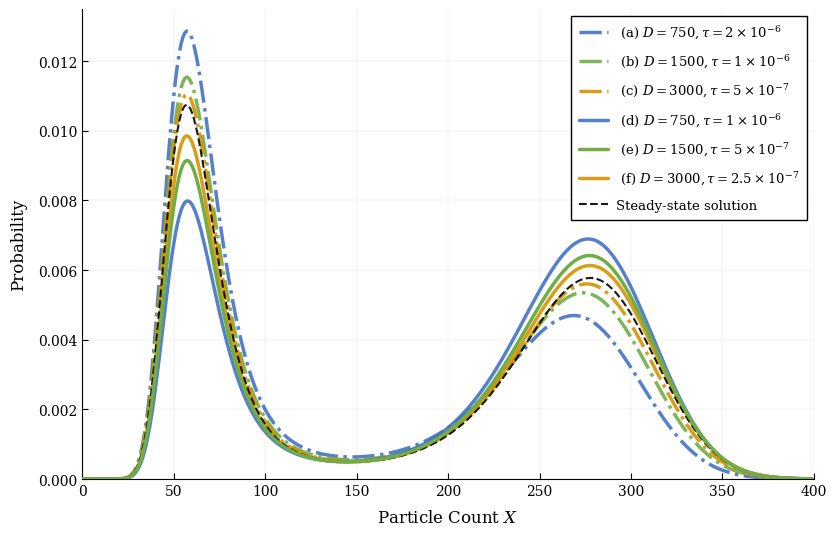

In [15]:

def generate_shoegl_Q(x_state: np.ndarray, kappa: np.ndarray, a, b, vol):
    """
    Generates the transition rate matrix Q for the Schlögl model.
    """
    rank = x_state.size
    Q = np.zeros((rank, rank))

    lamb_n = lambda y: a * kappa[0] * y * (y - 1) / vol + b * kappa[2] * vol
    mu_n = lambda y: y * kappa[3] + kappa[1] * y * (y - 1) * (y - 2) / (vol**2)
  
    Q_mu, Q_lamb = mu_n(x_state), lamb_n(x_state)    
    
    Q[np.eye(rank, k=1, dtype='bool')] = Q_mu[1:]
    Q[np.eye(rank, k=-1, dtype='bool')] = Q_lamb[:-1]
    
    # Boundary condition to ensure rows/columns sum correctly
    Q_lamb[-1] = 0.0 
    np.fill_diagonal(Q, -(Q_lamb + Q_mu))

    return Q

def plot_analytical_distributions(configs, vol, a=10, b=20, max_state=400):
    """
    Computes and plots the stationary distributions for different achieved rate configurations.
    
    Args:
        configs: Dictionary of configuration names to their achieved rate arrays (l1+, l1-, l2+, l2-, l3+, l3-).
        vol: System volume.
        a: Concentration/number of species A.
        b: Concentration/number of species B.
        max_state: Maximum number of X particles to compute the state space for.
    """
    # 1. Setup Aesthetics - Publication-quality
    plt.rcParams.update({
        'font.family': 'serif',  # Traditional academic style
        'font.size': 11,
        'axes.labelsize': 12,
        'axes.titlesize': 13,
        'legend.fontsize': 9.5,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': True,
        'axes.spines.bottom': True,
        'axes.linewidth': 1,
    })
    
    fig, ax = plt.subplots(figsize=(8.5, 5.5))  # Standard paper size
    p_states = np.arange(0, max_state, 1)
    
    # Publication-quality grayscale-friendly palette (prints well in B&W)
    colors = ['#4472C4',  '#70AD47', "#D39400",'#4472C4', '#70AD47', '#d39400', '#000000']  # Blue, Green, Gold, Brown, Black #"#EF15EC",  ####'#FFC000',"#FFC000",
    linestyles = [ '-.',  '-.', '-.', '-', '-','-', '--']  # Different dash patterns for B&W #':','-''-.''--'
    linewidths = [2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 1.5]    # Thicker for theoretical target
    
    # 2. Compute and Plot each configuration
    for i, (label, rates) in enumerate(configs.items()):
        
        l = np.array(rates)
        print(f'ratio of the second channel: {l[2]/l[3]:.4f}')
        kappa_schloegl = np.array([
            l[2] * l[0] / l[1], 
            l[3] * l[0] / l[1], 
            l[4], 
            l[5]
        ])
        
        Q = generate_shoegl_Q(p_states, kappa_schloegl, a, b, vol=vol)

        # Find stationary distribution
        eigenvalues, eigenvectors = np.linalg.eig(Q)
        id_max = np.argmax(np.isclose(eigenvalues, 0))
        
        stat_dist = np.real(eigenvectors[:, id_max])
        stat_dist /= stat_dist.sum()
        
        # Styling: Use line styles for B&W compatibility
        zorder = 20 if i == 4 else 10  # Last entry (index 4) is theoretical target
        alpha = 1.0 if i == 4 else 0.9
        
        ax.plot(p_states, stat_dist, label=label, 
               color=colors[i], 
               linestyle=linestyles[i],
               linewidth=linewidths[i], 
               alpha=alpha, 
               zorder=zorder,
               solid_capstyle='round',
               solid_joinstyle='round')

    # 3. Axis styling
    ax.set_xlabel(r'Particle Count $X$', fontsize=12, labelpad=8, fontweight='normal')
    ax.set_ylabel('Probability', fontsize=12, labelpad=8, fontweight='normal')
    
    ax.set_xlim(0, 400)
    ax.set_ylim(bottom=0, top=0.0135)
    
    # Minimal grid: academic standard
    ax.grid(True, linestyle='-', alpha=0.25, color='gray', linewidth=0.3, which='major')
    ax.set_axisbelow(True)
    
    # 4. Ticks styling
    ax.tick_params(
        axis='both',
        labelsize=10,
        direction='in',
        length=4,
        width=0.8,
        colors='black'
    )
    
    # 5. Legend: inside plot, upper right, minimal frame
    ax.legend(
        frameon=True,
        fancybox=False,
        edgecolor='black',
        facecolor='white',
        fontsize=9.5,
        loc='upper right',
        framealpha=1.0,
        borderpad=0.6,
        labelspacing=0.9,
        handlelength=2.2,
        handletextpad=0.6
    )
    
    # 6. Spine styling
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('black')
    
    plt.tight_layout()
    plt.savefig("prediction2.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# Execution
# ==========================================
if __name__ == "__main__":
    SYSTEM_VOL = 8.0
    
    rate_configs = {
        # n1=20000, n2=5000
            r" (a) $D=750, \tau=2\times10^{-6}$":  [1.499940, 1500, 150.961190, 25.584481, 5.75, 25 ],
            r" (b) $D=1500, \tau=1\times10^{-6}$":  [1.500026,1500, 150.501288, 25.282129, 5.75, 25],
            r" (c) $D=3000, \tau=5\times10^{-7}$":  [1.500069, 1500, 150.259643, 25.139464, 5.75, 25],

            r" (d) $D=750, \tau=1\times10^{-6}$":  [1.500208, 1500, 151.398089, 25.445299, 5.75, 25 ],
            r" (e) $D=1500, \tau=5\times10^{-7}$":  [1.500160, 1500, 150.708939, 25.217480, 5.75, 25],
            r" (f) $D=3000, \tau=2.5\times10^{-7}$":  [1.500136, 1500, 150.360984, 25.108267, 5.75, 25],
            "Steady-state solution":             [1.5,      1500, 150,        25,        5.75, 25]
        }

    plot_analytical_distributions(rate_configs, vol=SYSTEM_VOL)

In [16]:
rate_configs = {
    # n1=2000, n2=500
        r"$D=1500, \tau=1\times10^{-6}$": [ 1.501055, 1500, 150.831454, 25.337592, 5.75, 25],
        r"$D=1500, \tau=2\times10^{-7}$": [ 1.501339, 1500, 152.095798, 25.389369, 5.75, 25],
        r"$D=750, \tau=1\times10^{-6}$":  [1.501299, 1500, 152.485688, 25.628090, 5.75, 25],
        r"$D=750, \tau=2\times10^{-6}$":  [1.500985, 1500, 151.524092, 25.679880, 5.75, 25],
        "Theoretical Target":             [1.5,      1500, 150,        25,        5.75, 25]
    }